Electric Vehicle Data Analysis

Objective
The objective of this project is to analyze the Electric Vehicle Population dataset to identify trends, clean the data, perform exploratory data analysis (EDA), visualize important patterns, and generate business insights.

In [53]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [55]:
# Load Dataset

df = pd.read_csv("ev_dataset.csv.csv")
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5UX43EU07S,Snohomish,Snohomish,WA,98296.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,44.0,279314360,POINT (-122.1389 47.87115),PUGET SOUND ENERGY INC,5.306105e+10
1,5YJ3E1EB5J,Yakima,Yakima,WA,98901.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,220635992,POINT (-120.50729 46.60464),PACIFICORP,5.307700e+10
2,WA1AAAGE5M,King,Seattle,WA,98112.0,2021,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,222.0,43.0,282112967,POINT (-122.30207 47.64085),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJXCAE2XG,Kitsap,Bremerton,WA,98310.0,2016,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200.0,23.0,103165100,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
4,5YJ3E1EB5J,Yakima,Yakima,WA,98908.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,301024209,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10


In [56]:
# Shape of Dataset
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 289564
Number of Columns : 16


In [57]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289564 entries, 0 to 289563
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         289564 non-null  object 
 1   County                                             289555 non-null  object 
 2   City                                               289555 non-null  object 
 3   State                                              289564 non-null  object 
 4   Postal Code                                        289555 non-null  float64
 5   Model Year                                         289564 non-null  int64  
 6   Make                                               289564 non-null  object 
 7   Model                                              289564 non-null  object 
 8   Electric Vehicle Type                              289564 non-null  object

In [58]:
# Column Names
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')

In [59]:
# Statistical Summary
df.describe(include="all")

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
count,289564,289555,289555,289564,289555.000000,289564.000000,289564,289564,289564,289564,289554.000000,288837.000000,2.895640e+05,289548,289555,2.895550e+05
unique,17883,249,920,53,NaN,NaN,49,198,2,3,NaN,NaN,NaN,1156,77,NaN
top,7SAYGDEE6P,King,Seattle,WA,NaN,NaN,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,NaN,NaN,NaN,POINT (-122.13158 47.67858),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),NaN
freq,1196,140130,44333,288838,NaN,NaN,118148,62979,233544,188456,NaN,NaN,NaN,6950,100741,NaN
mean,NaN,NaN,NaN,NaN,98179.343375,2022.255957,NaN,NaN,NaN,NaN,37.399770,28.800787,2.495999e+08,NaN,NaN,5.297009e+10
std,NaN,NaN,NaN,NaN,2595.465980,3.080426,NaN,NaN,NaN,NaN,76.741728,14.888276,6.267330e+07,NaN,NaN,1.656928e+09
min,NaN,NaN,NaN,NaN,1030.000000,1999.000000,NaN,NaN,NaN,NaN,0.000000,1.000000,4.385000e+03,NaN,NaN,1.001020e+09
25%,NaN,NaN,NaN,NaN,98052.000000,2021.000000,NaN,NaN,NaN,NaN,0.000000,17.000000,2.271862e+08,NaN,NaN,5.303301e+10
50%,NaN,NaN,NaN,NaN,98133.000000,2023.000000,NaN,NaN,NaN,NaN,0.000000,32.000000,2.670574e+08,NaN,NaN,5.303303e+10
75%,NaN,NaN,NaN,NaN,98388.000000,2024.000000,NaN,NaN,NaN,NaN,32.000000,42.000000,2.827402e+08,NaN,NaN,5.305394e+10


In [60]:
# Missing Values
df.isnull().sum()

VIN (1-10)                                             0
County                                                 9
City                                                   9
State                                                  0
Postal Code                                            9
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        10
Legislative District                                 727
DOL Vehicle ID                                         0
Vehicle Location                                      16
Electric Utility                                       9
2020 Census Tract                                      9
dtype: int64

In [61]:
# Missing Value Percentage
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Legislative District,727,0.251067
Vehicle Location,16,0.005526
Electric Range,10,0.003453
County,9,0.003108
City,9,0.003108
Postal Code,9,0.003108
Electric Utility,9,0.003108
2020 Census Tract,9,0.003108
VIN (1-10),0,0.000000
State,0,0.000000


In [12]:
# Check Duplicate Records
duplicate_rows = df.duplicated().sum()
print("Duplicate Rows :", duplicate_rows)

Duplicate Rows : 0


In [13]:
# Remove Duplicate Records
df = df.drop_duplicates()
print("Dataset Shape After Removing Duplicates")
print(df.shape)

Dataset Shape After Removing Duplicates
(289564, 16)


In [14]:
# Check Data Types
df.dtypes

VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract                                    float64
dtype: object

In [17]:
# Fill Missing Values
# Fill categorical missing values only when the column exists
for col, fill_value in {
    "Electric Utility": "Unknown"
}.items():
    if col in df.columns:
        df[col] = df[col].fillna(fill_value)

for col in ["Legislative District", "Postal Code"]:
    if col in df.columns:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)

# Electric Range
if "Electric Range" in df.columns:
    df["Electric Range"] = df["Electric Range"].fillna(
        df["Electric Range"].median()
    )

# Base MSRP
if "Base MSRP" in df.columns:
    df["Base MSRP"] = df["Base MSRP"].replace(0, np.nan)
    df["Base MSRP"] = df["Base MSRP"].fillna(
        df["Base MSRP"].median()
    )

missing_columns = [col for col in ["Electric Utility", "Legislative District", "Postal Code", "Electric Range", "Base MSRP"] if col not in df.columns]
if missing_columns:
    print("Columns not present in the dataset and skipped:", missing_columns)

Columns not present in the dataset and skipped: ['Base MSRP']


In [18]:
# Verify Missing Values
df.isnull().sum()

VIN (1-10)                                            0
County                                                9
City                                                  9
State                                                 0
Postal Code                                           0
Model Year                                            0
Make                                                  0
Model                                                 0
Electric Vehicle Type                                 0
Clean Alternative Fuel Vehicle (CAFV) Eligibility     0
Electric Range                                        0
Legislative District                                  0
DOL Vehicle ID                                        0
Vehicle Location                                     16
Electric Utility                                      0
2020 Census Tract                                     9
dtype: int64

In [19]:
# Unique Values
print("Number of Makes :", df["Make"].nunique())
print("Number of Models :", df["Model"].nunique())
print("Number of Counties :", df["County"].nunique())
print("Number of Cities :", df["City"].nunique())

Number of Makes : 49
Number of Models : 198
Number of Counties : 249
Number of Cities : 920


In [20]:
# Dataset After Cleaning
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5UX43EU07S,Snohomish,Snohomish,WA,98296.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,44.0,279314360,POINT (-122.1389 47.87115),PUGET SOUND ENERGY INC,5.306105e+10
1,5YJ3E1EB5J,Yakima,Yakima,WA,98901.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,220635992,POINT (-120.50729 46.60464),PACIFICORP,5.307700e+10
2,WA1AAAGE5M,King,Seattle,WA,98112.0,2021,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,222.0,43.0,282112967,POINT (-122.30207 47.64085),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJXCAE2XG,Kitsap,Bremerton,WA,98310.0,2016,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200.0,23.0,103165100,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
4,5YJ3E1EB5J,Yakima,Yakima,WA,98908.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,301024209,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10


In [21]:
# Save Cleaned Dataset
df.to_csv("Electric_Vehicle_Cleaned.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


Make
TESLA         118148
CHEVROLET      19808
NISSAN         16023
FORD           15930
KIA            14501
TOYOTA         13057
BMW            12024
HYUNDAI        11696
RIVIAN          9491
VOLKSWAGEN      7863
Name: count, dtype: int64


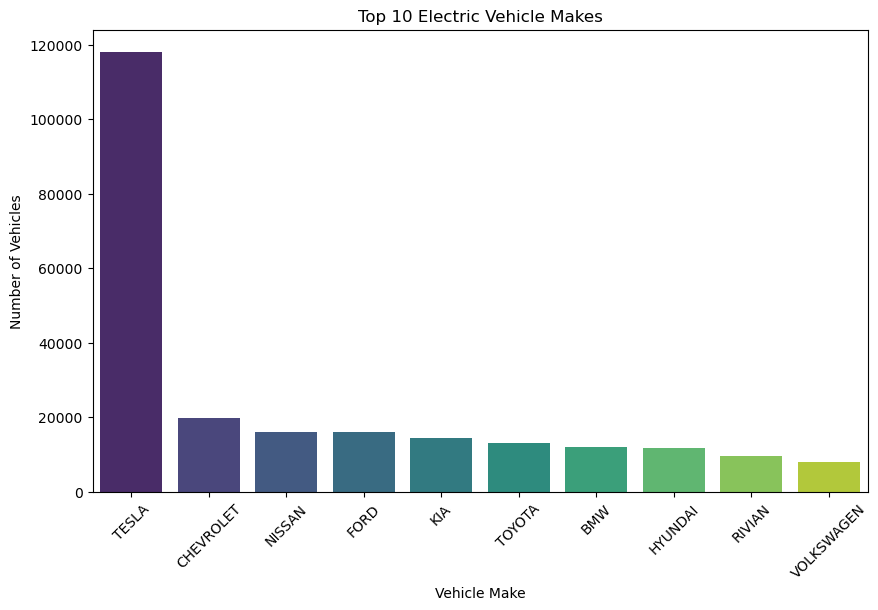

In [22]:
# Top 10 Electric Vehicle Makes
top_makes = df["Make"].value_counts().head(10)
print(top_makes)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_makes.index,
    y=top_makes.values,
    palette="viridis"
)
plt.title("Top 10 Electric Vehicle Makes")
plt.xlabel("Vehicle Make")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.show()

Model
MODEL Y           62979
MODEL 3           38325
LEAF              13406
MODEL S            7784
BOLT EV            7518
MODEL X            7106
IONIQ 5            7053
MUSTANG MACH-E     6764
ID.4               6312
R1S                5504
Name: count, dtype: int64


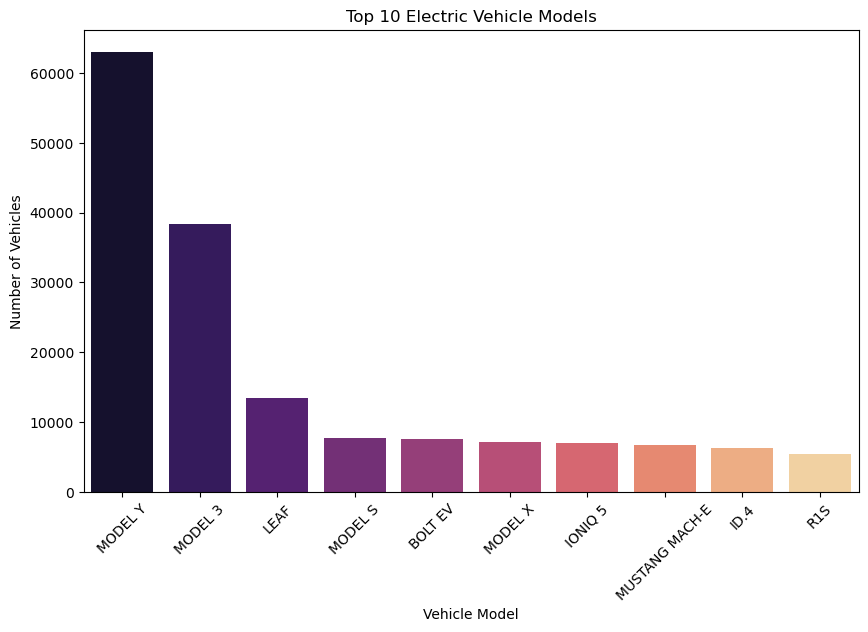

In [23]:
# Top 10 Electric Vehicle Models
top_models = df["Model"].value_counts().head(10)
print(top_models)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_models.index,
    y=top_models.values,
    palette="magma"
)
plt.title("Top 10 Electric Vehicle Models")
plt.xlabel("Vehicle Model")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.show()

Electric Vehicle Type
Battery Electric Vehicle (BEV)            233544
Plug-in Hybrid Electric Vehicle (PHEV)     56020
Name: count, dtype: int64


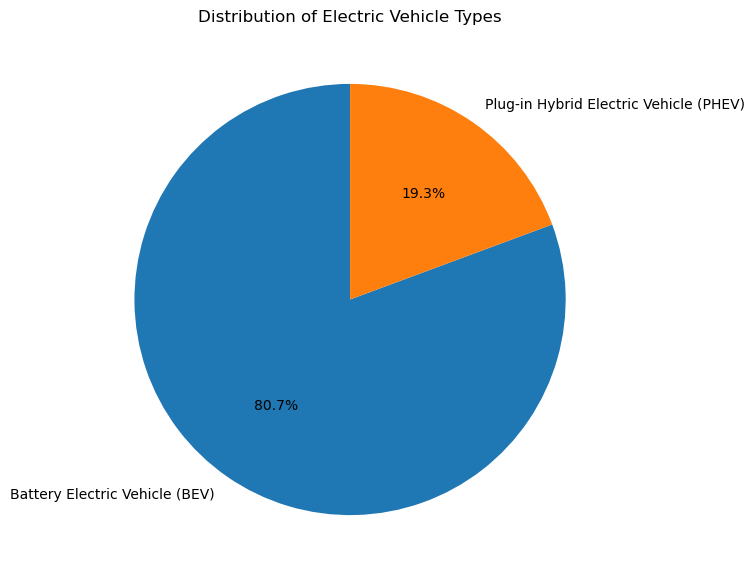

In [24]:
# Electric Vehicle Type Distribution
vehicle_type = df["Electric Vehicle Type"].value_counts()
print(vehicle_type)
plt.figure(figsize=(7,7))
plt.pie(
    vehicle_type,
    labels=vehicle_type.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Electric Vehicle Types")
plt.show()

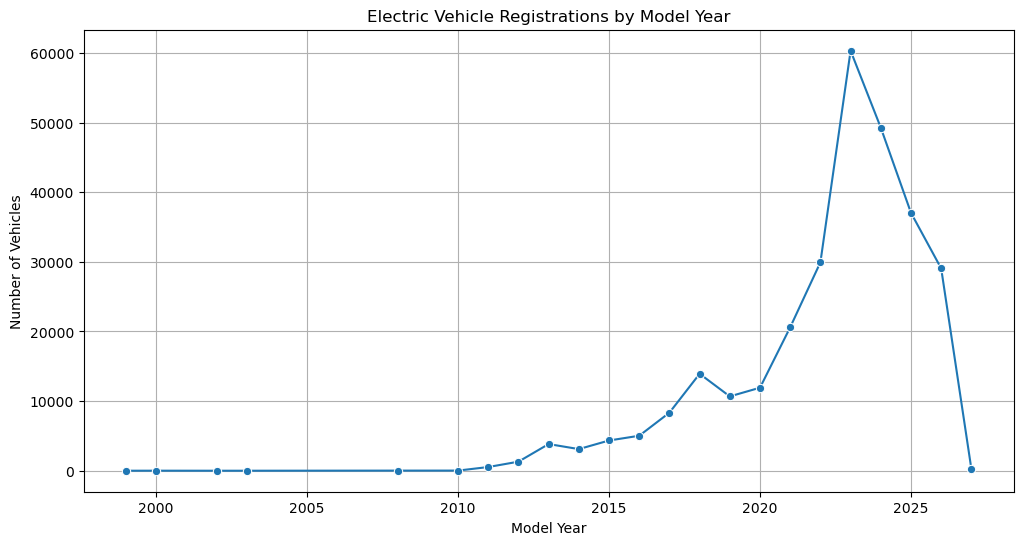

In [25]:
# EV Registrations by Model Year
year_data = df["Model Year"].value_counts().sort_index()
plt.figure(figsize=(12,6))
sns.lineplot(
    x=year_data.index,
    y=year_data.values,
    marker="o"
)
plt.title("Electric Vehicle Registrations by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
plt.grid(True)
plt.show()

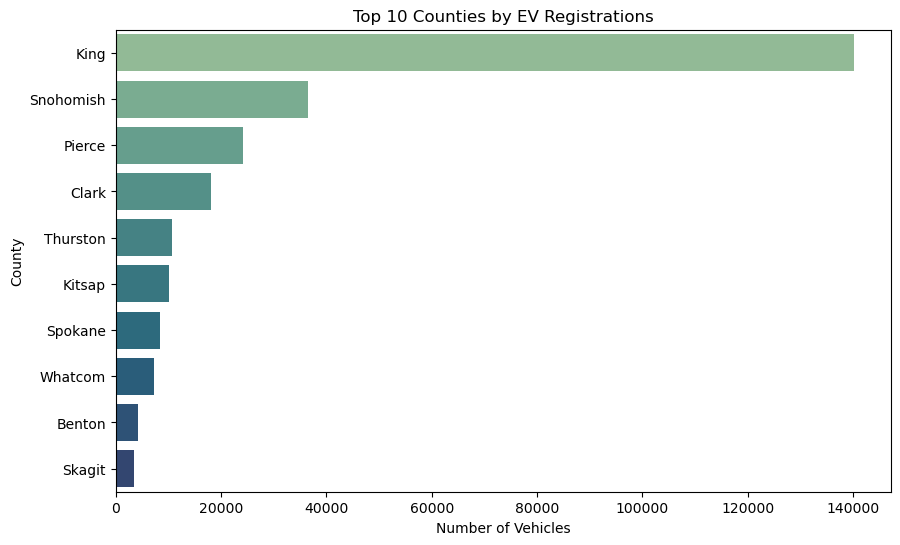

In [26]:
# Top 10 Counties
county = df["County"].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=county.values,
    y=county.index,
    palette="crest"
)
plt.title("Top 10 Counties by EV Registrations")
plt.xlabel("Number of Vehicles")
plt.ylabel("County")
plt.show()

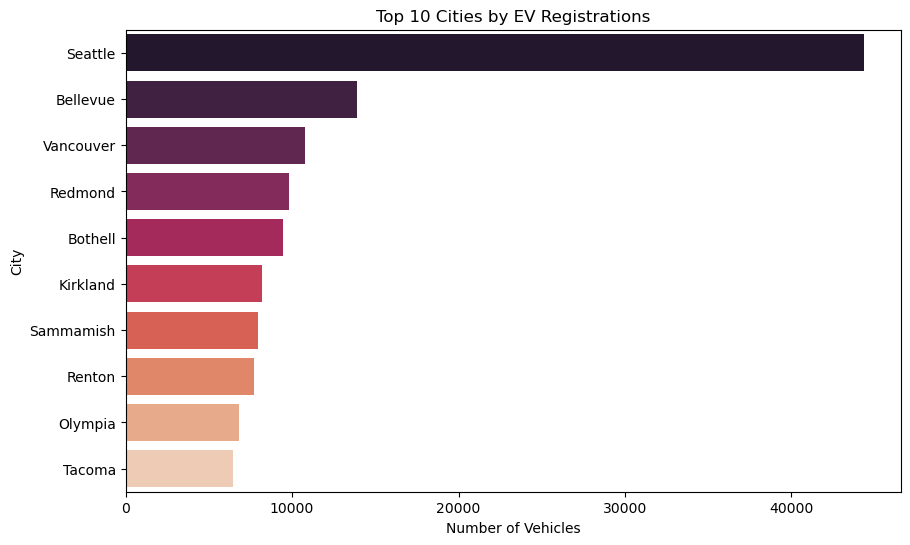

In [27]:
# Top 10 Cities
city = df["City"].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=city.values,
    y=city.index,
    palette="rocket"
)
plt.title("Top 10 Cities by EV Registrations")
plt.xlabel("Number of Vehicles")
plt.ylabel("City")
plt.show()

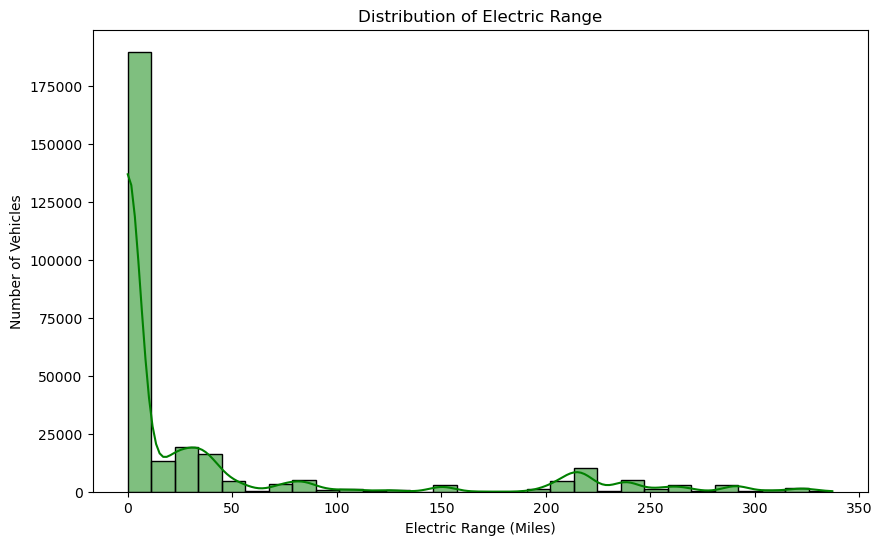

In [28]:
# Electric Range Distribution
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="Electric Range",
    bins=30,
    kde=True,
    color="green"
)
plt.title("Distribution of Electric Range")
plt.xlabel("Electric Range (Miles)")
plt.ylabel("Number of Vehicles")
plt.show()

In [30]:
# Base MSRP Distribution
if "Base MSRP" in df.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(
        data=df,
        x="Base MSRP",
        bins=30,
        kde=True,
        color="orange"
    )
    plt.title("Distribution of Base MSRP")
    plt.xlabel("Base MSRP")
    plt.ylabel("Number of Vehicles")
    plt.show()
else:
    print("Base MSRP column is not available in this dataset.")

Base MSRP column is not available in this dataset.


Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    188456
Clean Alternative Fuel Vehicle Eligible                          77580
Not eligible due to low battery range                            23528
Name: count, dtype: int64


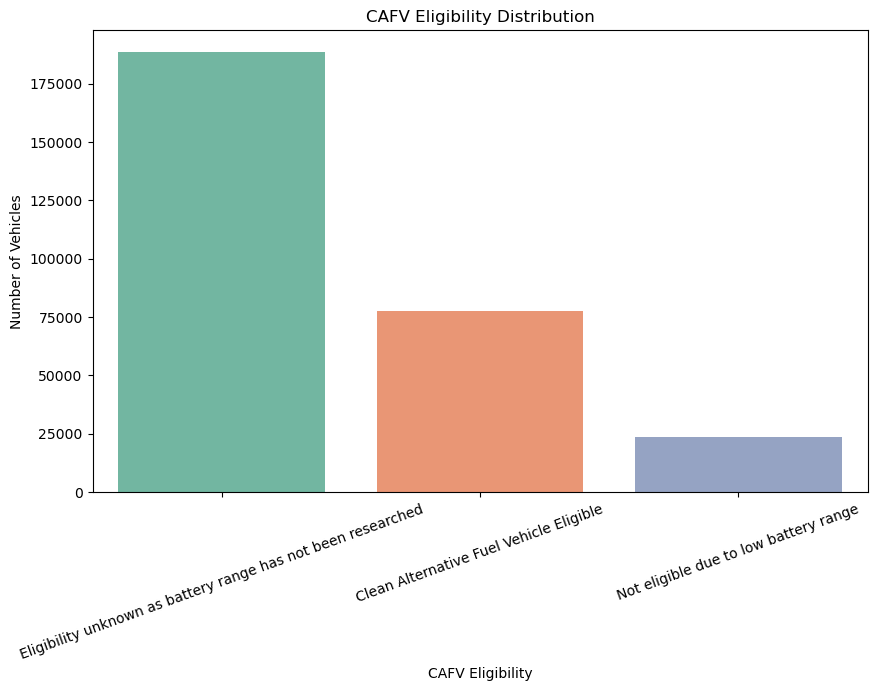

In [31]:
# CAFV Eligibility Analysis
cafv = df["Clean Alternative Fuel Vehicle (CAFV) Eligibility"].value_counts()
print(cafv)
plt.figure(figsize=(10,6))
sns.barplot(
    x=cafv.index,
    y=cafv.values,
    palette="Set2"
)
plt.title("CAFV Eligibility Distribution")
plt.xlabel("CAFV Eligibility")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=20)
plt.show()

In [33]:
# Electric Range vs Base MSRP
if "Base MSRP" in df.columns and "Electric Range" in df.columns:
    plt.figure(figsize=(10,6))
    sns.scatterplot(
        data=df,
        x="Base MSRP",
        y="Electric Range",
        alpha=0.6
    )
    plt.title("Electric Range vs Base MSRP")
    plt.xlabel("Base MSRP")
    plt.ylabel("Electric Range")
    plt.show()
else:
    print("Required columns for the scatter plot are not available in this dataset.")

Required columns for the scatter plot are not available in this dataset.


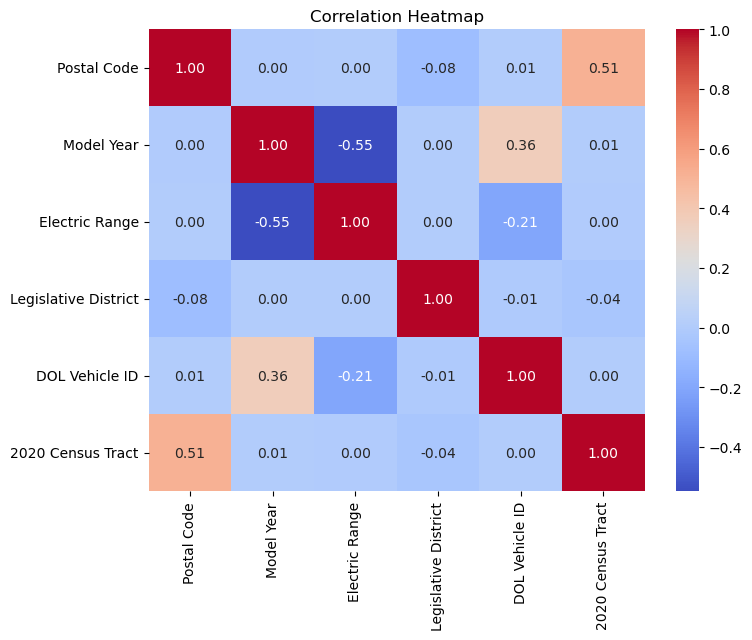

In [34]:
# Correlation Heatmap
numeric_columns = df.select_dtypes(include=["number"])
plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

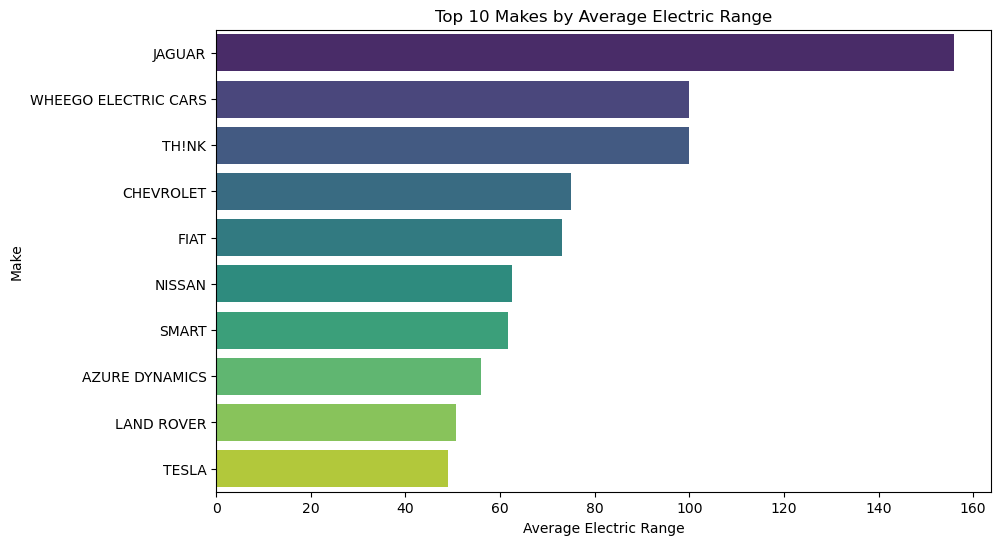

In [35]:
# Average Electric Range by Make
avg_range = (
    df.groupby("Make")["Electric Range"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(10,6))
sns.barplot(
    x=avg_range.values,
    y=avg_range.index,
    palette="viridis"
)
plt.title("Top 10 Makes by Average Electric Range")
plt.xlabel("Average Electric Range")
plt.ylabel("Make")
plt.show()


In [37]:
# Average Base MSRP by Make
if "Base MSRP" in df.columns:
    avg_price = (
        df.groupby("Make")["Base MSRP"]
          .mean()
          .sort_values(ascending=False)
          .head(10)
    )
    plt.figure(figsize=(10,6))
    sns.barplot(
        x=avg_price.values,
        y=avg_price.index,
        palette="magma"
    )
    plt.title("Average Base MSRP by Make")
    plt.xlabel("Average Base MSRP")
    plt.ylabel("Vehicle Make")
    plt.show()
else:
    print("Base MSRP column is not available in this dataset.")

Base MSRP column is not available in this dataset.


In [38]:
# Average Electric Range
average_range = df["Electric Range"].mean()
print(f"Average Electric Range : {average_range:.2f} miles")

Average Electric Range : 37.40 miles


In [40]:
# Average Base MSRP by Model
if "Base MSRP" in df.columns:
    avg_msrp = (
        df.groupby("Model")["Base MSRP"]
          .mean()
          .sort_values(ascending=False)
    )

    avg_msrp.head(10)
else:
    print("Base MSRP column is not available in this dataset.")

Base MSRP column is not available in this dataset.


In [42]:
# Top 10 Models by Average Base MSRP
if "Base MSRP" in df.columns:
    top_price = (
        df.groupby("Model")["Base MSRP"]
          .mean()
          .sort_values(ascending=False)
          .head(10)
    )
    plt.figure(figsize=(12,6))
    sns.barplot(
        x=top_price.values,
        y=top_price.index,
        palette="mako"
    )
    plt.title("Top 10 Models by Average Base MSRP")
    plt.xlabel("Average Base MSRP")
    plt.ylabel("Model")
    plt.show()
else:
    print("Base MSRP column is not available in this dataset.")

Base MSRP column is not available in this dataset.


In [43]:
# CAFV Eligibility Percentage
if "Clean Alternative Fuel Vehicle (CAFV) Eligibility" in df.columns:
    cafv_percentage = (
        df["Clean Alternative Fuel Vehicle (CAFV) Eligibility"]
          .value_counts(normalize=True) * 100
    )
print(cafv_percentage.round(2))

Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    65.08
Clean Alternative Fuel Vehicle Eligible                         26.79
Not eligible due to low battery range                            8.13
Name: proportion, dtype: float64


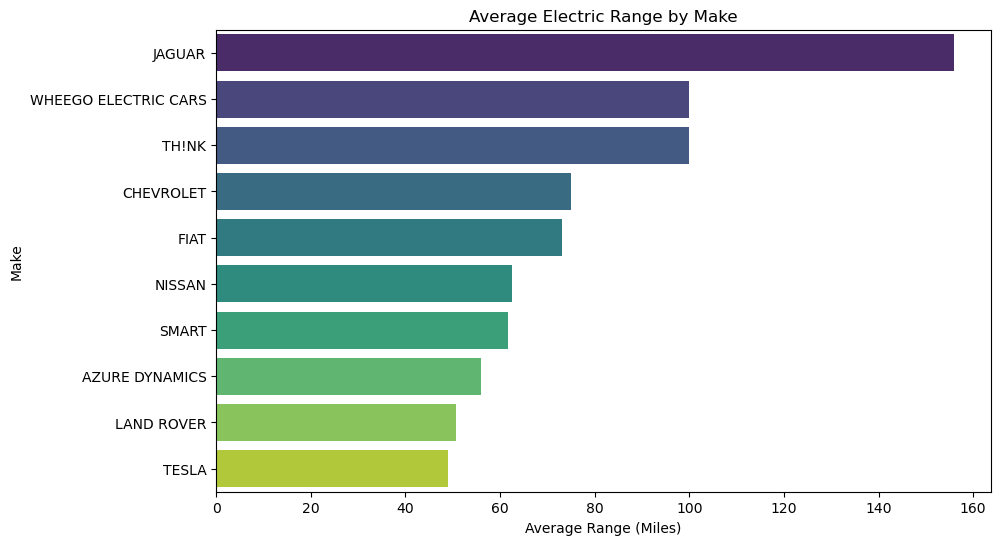

In [44]:
# Average Electric Range by Top Makes
top_range = (
    df.groupby("Make")["Electric Range"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_range.values,
    y=top_range.index,
    palette="viridis"
)
plt.title("Average Electric Range by Make")
plt.xlabel("Average Range (Miles)")
plt.ylabel("Make")
plt.show()

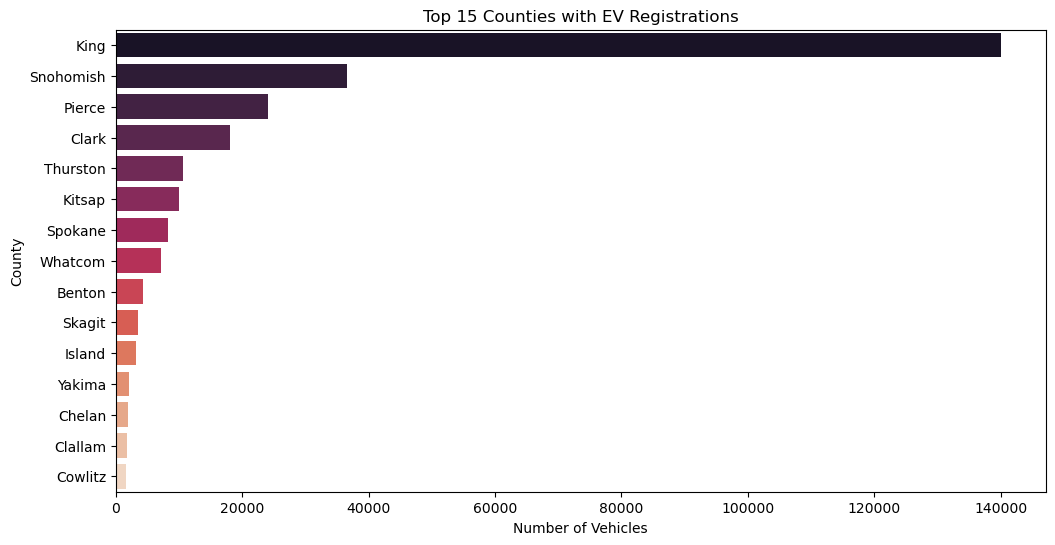

In [45]:
# Regional Trend
county_data = df["County"].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(
    x=county_data.values,
    y=county_data.index,
    palette="rocket"
)
plt.title("Top 15 Counties with EV Registrations")
plt.xlabel("Number of Vehicles")
plt.ylabel("County")
plt.show()

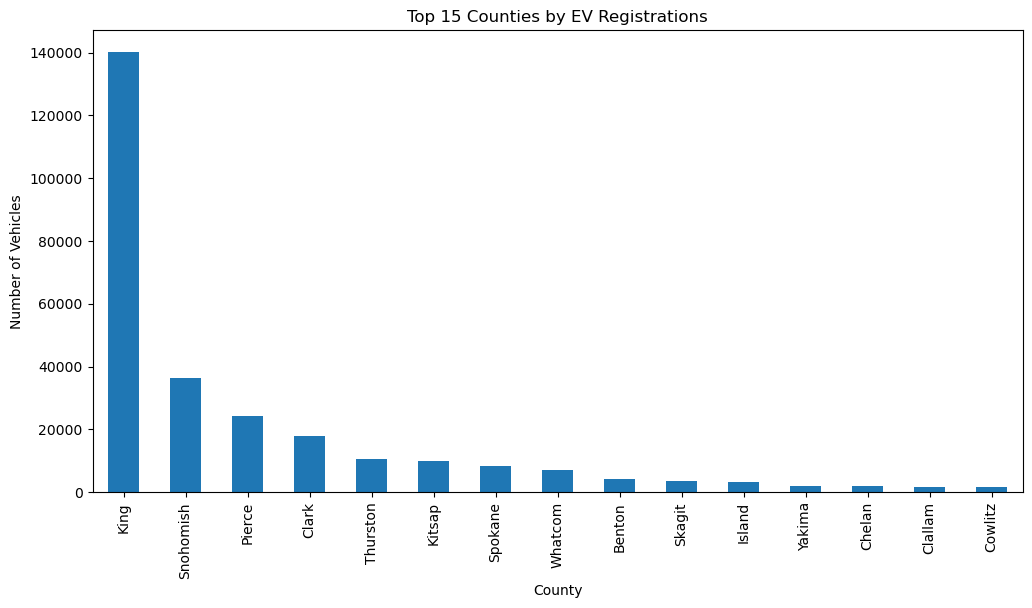

In [69]:
# Regional Distribution of EV Registrations
plt.figure(figsize=(12,6))

county_counts = df["County"].value_counts().head(15)

county_counts.plot(kind="bar")

plt.title("Top 15 Counties by EV Registrations")
plt.xlabel("County")
plt.ylabel("Number of Vehicles")

plt.show()

In [71]:
print(df.columns.tolist())

['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']


In [72]:
# Linear Regression Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare data
data = df[["Model Year", "Electric Range"]].dropna()

X = data[["Model Year"]]
y = data["Electric Range"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, predictions)

print("R² Score:", round(r2, 3))

R² Score: 0.299


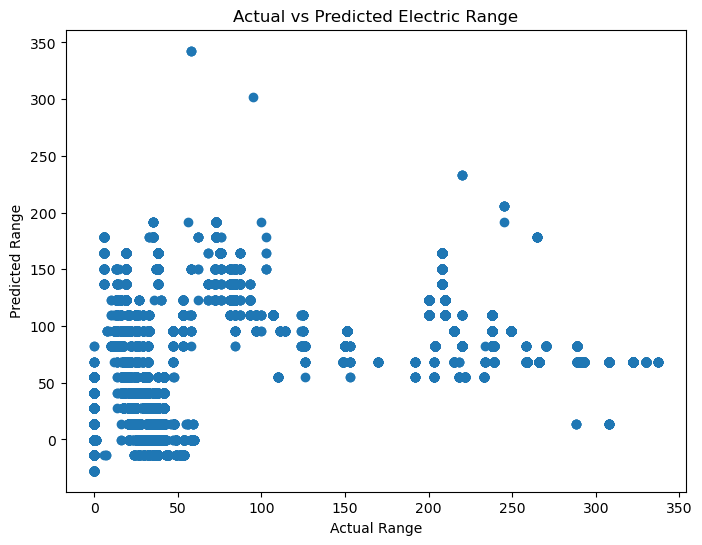

In [73]:
# Actual vs Predicted
plt.figure(figsize=(8,6))
if 'y_test' in locals() and 'predictions' in locals():
    plt.scatter(y_test, predictions)
    plt.xlabel("Actual Range")
    plt.ylabel("Predicted Range")
    plt.title("Actual vs Predicted Electric Range")
    plt.show()
else:
    print("Regression model output is not available. Run the regression model cell first.")

Linear Regression Interpretation

The Linear Regression model predicts the Electric Range of an electric vehicle using Model Year and Base MSRP as input features.

Model Evaluation
- The R² score indicates how well the model explains the variation in Electric Range.
- A higher R² value means better predictive performance.

Observation
- Base MSRP and Model Year influence Electric Range, but additional features such as Make, Model, Battery Capacity, and Vehicle Type could improve the model's accuracy.

Business Insights

1. EV registrations have increased significantly in recent model years.
2. Tesla and a few major manufacturers dominate the EV market.
3. Battery Electric Vehicles (BEVs) have higher registrations than Plug-in Hybrid Electric Vehicles (PHEVs).
4. EV adoption is concentrated in a few counties and cities.
5. Vehicles with higher electric ranges often have higher prices, though the relationship is not perfectly linear.
6. CAFV eligibility varies across different vehicle models.
7. Electric vehicle adoption continues to grow, indicating increasing demand for sustainable transportation.

Conclusion

This project analyzed the Electric Vehicle Population dataset using Python, Pandas, Matplotlib, and Seaborn. The analysis included data cleaning, handling missing values, exploratory data analysis, and visualization. Key trends in vehicle manufacturers, model popularity, EV types, electric range, pricing, and regional adoption were identified. These insights can help support business decisions, market analysis, and policy planning related to electric vehicles.